In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [53]:
# Load the dataset
conn = sqlite3.connect('inventory.db')

# fetching vendor summary data
df = pd.read_sql_query("select * from vendor_sales_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,60320,1584606.40,9578.0,344712.22,64889.97,17598.14,68601.68,-1239894.18,-359.689651,0.158786,0.217538
1,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,96073,1553500.41,20226.0,444810.74,43304.31,37163.76,257032.07,-1108689.67,-249.249753,0.210527,0.286328
2,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,62385,1446708.15,9203.0,275162.97,52289.50,16909.12,144929.24,-1171545.18,-425.764114,0.147519,0.190199
3,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,75385,1375022.40,11189.0,288135.11,48202.30,20557.97,123780.22,-1086887.29,-377.214457,0.148425,0.209549
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,58783,1286759.87,11883.0,357759.17,52774.51,21833.58,257032.07,-929000.70,-259.672086,0.202150,0.278031


 In this phase of EDA, we will analyze the table to gain the insights into the distribution of each column

In [54]:
# summary Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,8512.0,1.015346e+04,17718.122212,2.00,3664.000000,7153.000000,9552.000000,1.733570e+05
Brand,8512.0,1.760026e+04,13004.702546,58.00,5297.750000,17432.500000,24988.000000,9.063100e+04
PurchasePrice,8512.0,2.188977e+01,105.829821,0.36,6.800000,10.270000,18.240000,5.681810e+03
ActualPrice,8512.0,3.218842e+01,144.210224,0.49,10.990000,15.990000,26.990000,7.499990e+03
Volume,8512.0,8.548756e+02,617.982459,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,8512.0,1.691844e+03,5496.001551,1.00,24.000000,231.500000,1195.000000,1.607350e+05
TotalPurchaseDollars,8512.0,1.578656e+04,56938.194190,0.71,344.880000,2840.535000,12601.875000,1.584606e+06
TotalSalesQuantity,8512.0,2.872162e+02,967.741069,0.00,3.000000,34.000000,200.000000,2.854400e+04
TotalSalesDollars,8512.0,3.873112e+03,13541.331564,0.00,59.940000,649.745000,3129.827500,4.448107e+05
TotalSalesPrice,8512.0,1.890345e+03,4290.868376,0.00,22.692500,363.675000,1831.792500,6.488997e+04


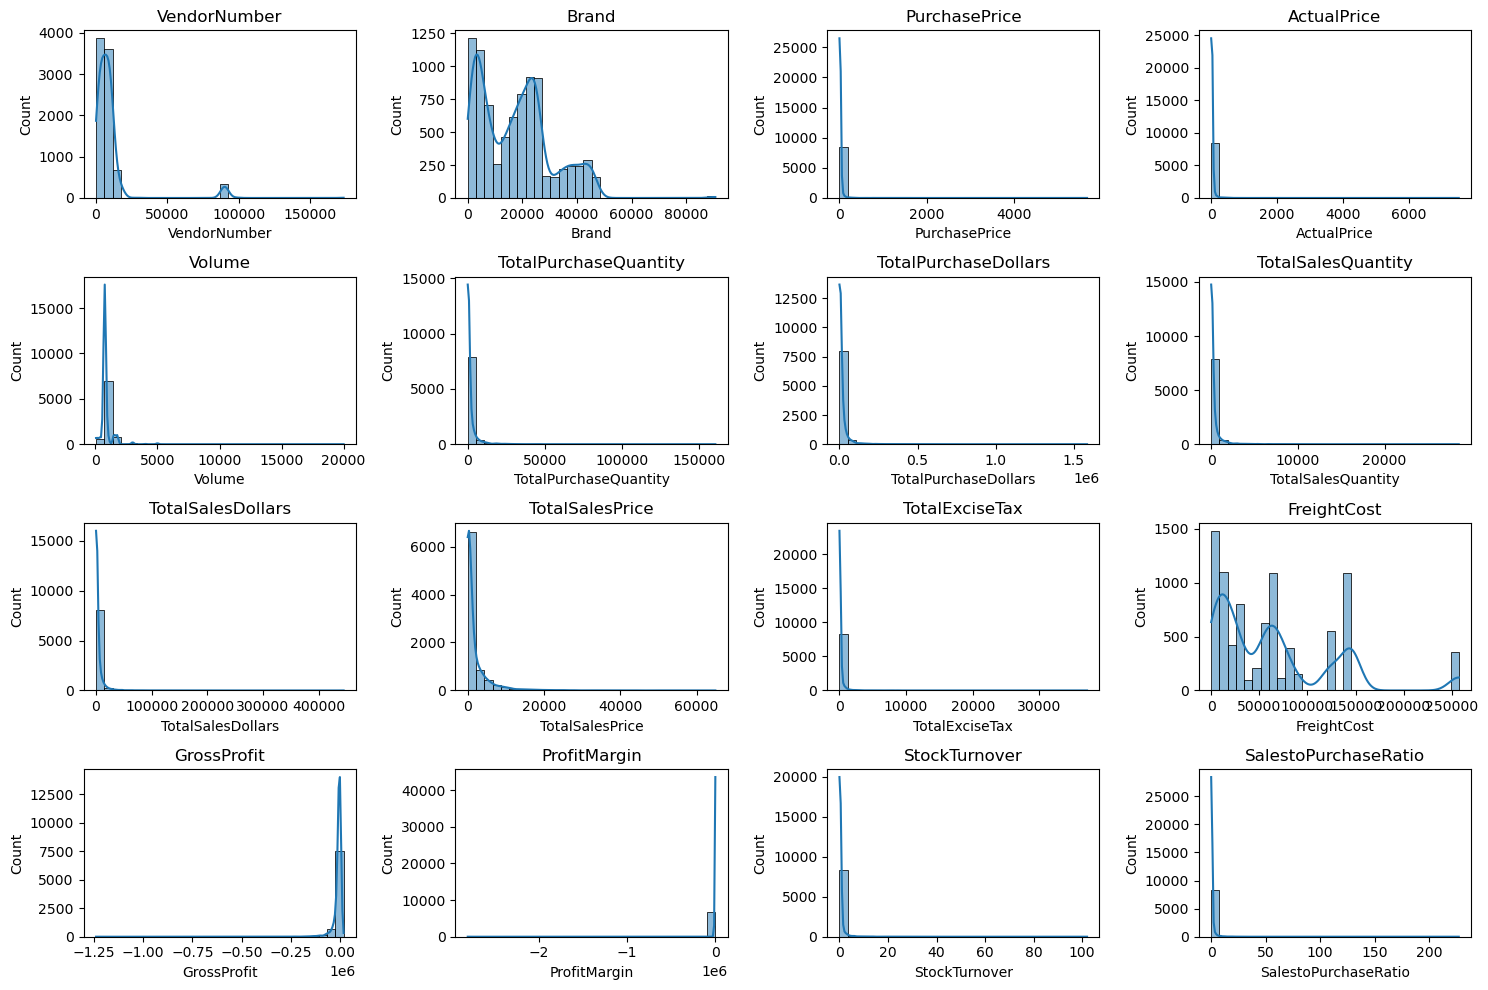

In [55]:
# distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


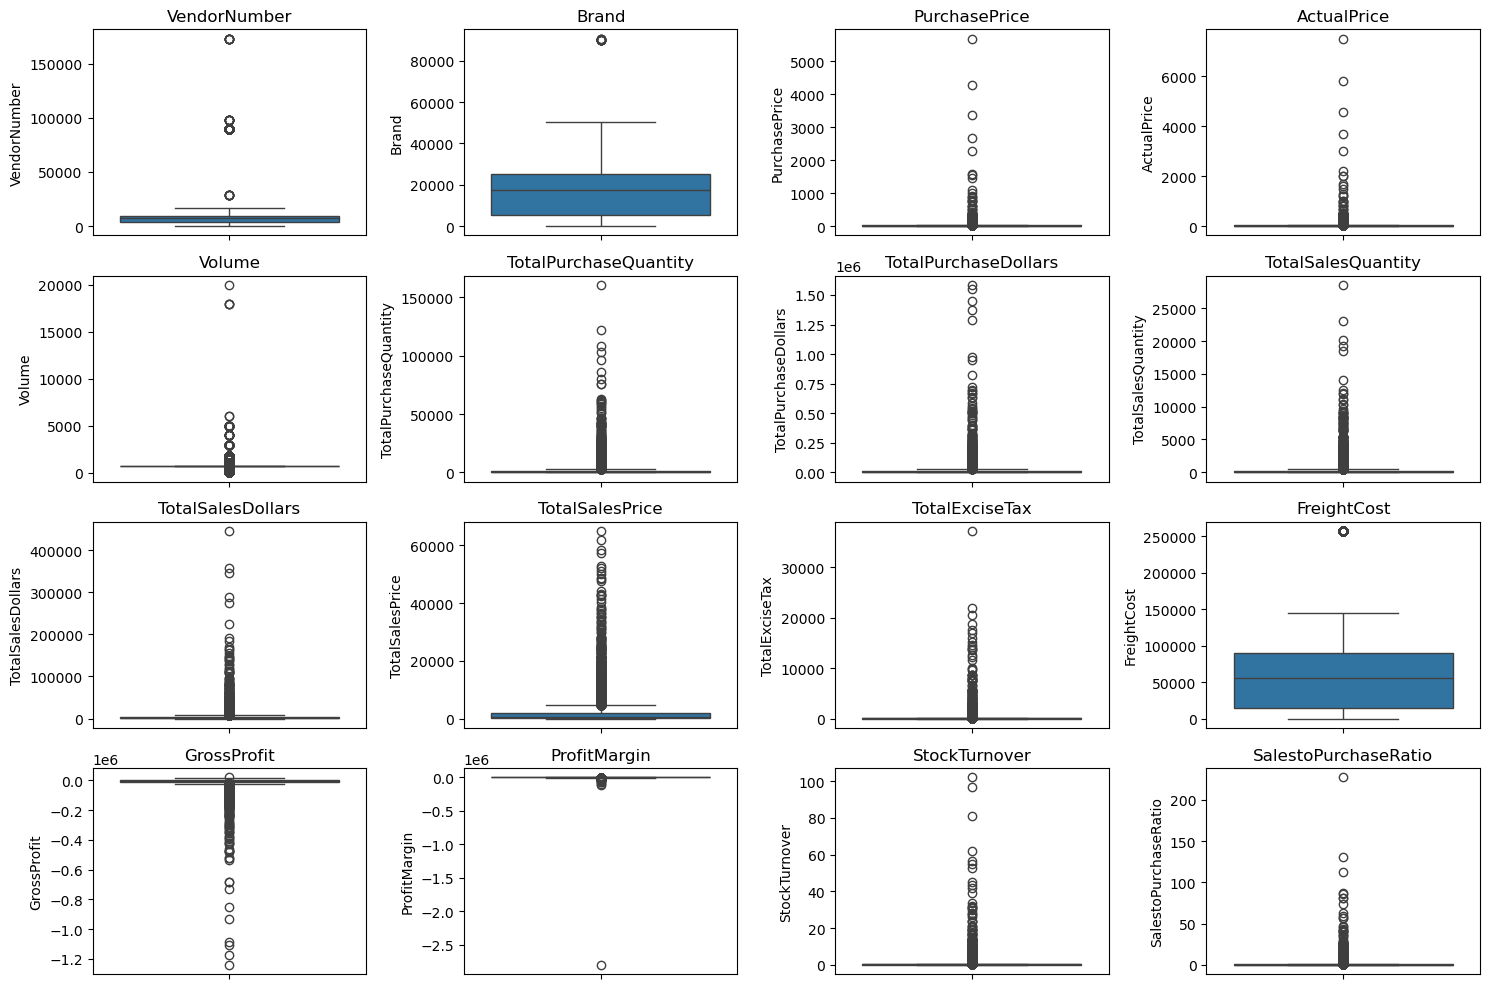

In [56]:
# Outlier Detection with Boxplots
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Summary Statistics Insights
1. On average, ActualPrice (32.19) is higher than PurchasePrice (21.89), suggesting that products are sold with a markup.
2. The average purchase quantity (1691) is much higher than the average sales quantity (287), indicating excess inventory or slow-moving products.
3. The mean Gross Profit is negative (-11,913), suggesting that many vendors are operating at a loss or facing inefficient cost management.
4. The average stock turnover is only 0.56, indicating that inventory is moving slowly, which may increase holding costs
5. Several variables such as Sales, Purchase Quantity, and Freight Cost show extreme outliers, meaning a few vendors dominate transactions and revenu
6. ProfitMargin contains infinite values due to zero sales for some vendors, highlighting data quality issues and inactive vendors

In [57]:
# Let's filter the data by removing inconsistencies
df = pd.read_sql_query("""SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""",conn)

In [58]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1392,CONSTELLATION BRANDS INC,6650,Simi Chard,7.38,14.99,750.0,11199,82648.62,8458.0,93369.42,13558.87,949.79,79528.99,10720.80,11.482132,0.755246,1.129715
1,1392,CONSTELLATION BRANDS INC,22143,Simi Cab Svgn,10.52,18.99,750.0,4194,44120.88,2887.0,46523.13,13703.56,323.21,79528.99,2402.25,5.163561,0.688364,1.054447
2,516,BANFI PRODUCTS CORP,18152,Banfi Centine Mntcln Tscna,5.26,10.99,750.0,5723,30102.98,3891.0,31728.09,7605.68,436.17,8510.41,1625.11,5.121991,0.679888,1.053985
3,10754,PERFECTA WINES,25197,Ch La Rousseliere St Estephe,99.33,149.99,750.0,249,24733.17,198.0,29698.02,1199.92,22.24,28720.52,4964.85,16.717781,0.795181,1.200737
4,4425,MARTIGNETTI COMPANIES,8781,Rodney Strong Cab Svgn,10.32,15.99,750.0,2241,23127.12,1840.0,31245.60,11934.97,205.53,144929.24,8118.48,25.982794,0.821062,1.351037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,90024,VINILANDIA USA,46135,Aresti Pnt Nr Curico Vly,3.28,10.99,750.0,1,3.28,15.0,74.85,39.92,1.68,2802.64,71.57,95.617902,15.000000,22.820122
978,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,3.0,5.97,5.97,0.33,27100.41,3.33,55.778894,1.500000,2.261364
979,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,128.0,62.72,0.98,6.72,50293.62,60.38,96.269133,21.333333,26.803419
980,9815,WINE GROUP INC,22407,Three Wishes Chard,2.25,3.29,750.0,1,2.25,1.0,3.29,3.29,0.11,27100.41,1.04,31.610942,1.000000,1.462222


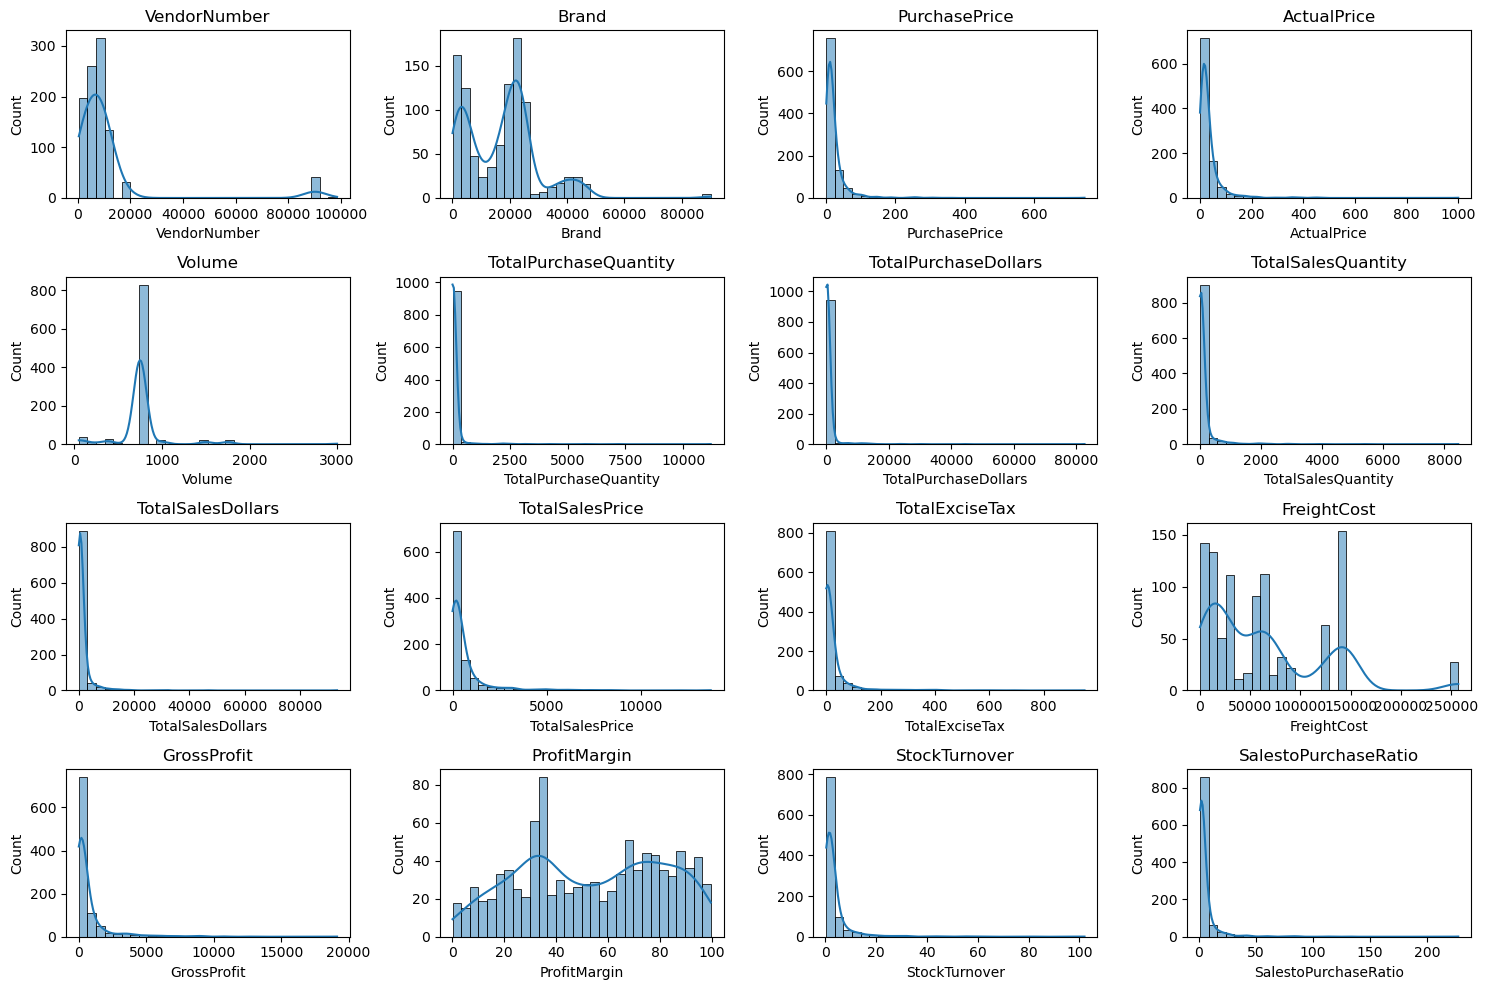

In [59]:
# distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

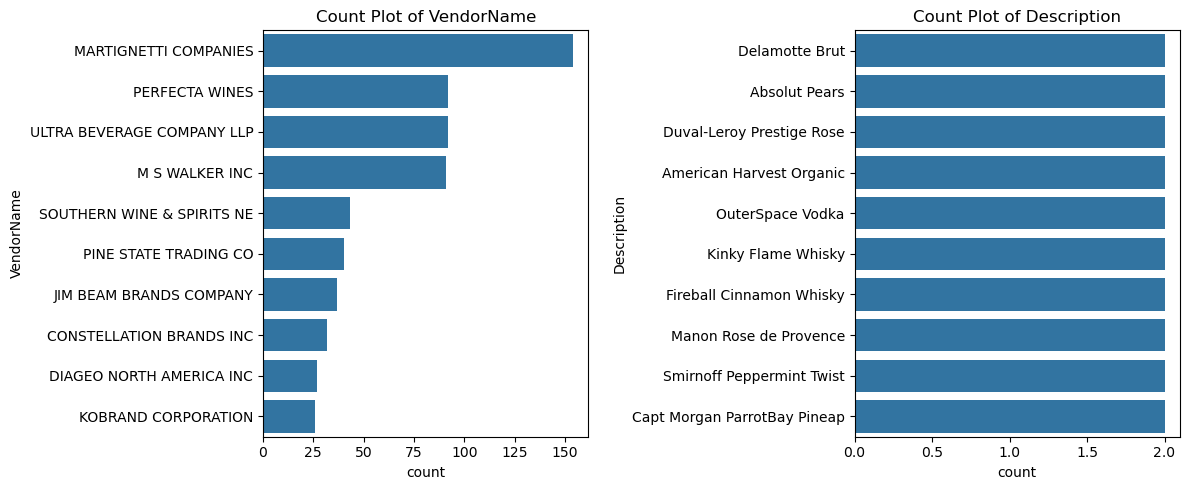

In [60]:
# Count Plots for categorical Columns
categorical_cols = ['VendorName','Description']

plt.figure(figsize=(12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)  
    sns.countplot(y=df[col], order =df[col].value_counts().index[:10])  # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

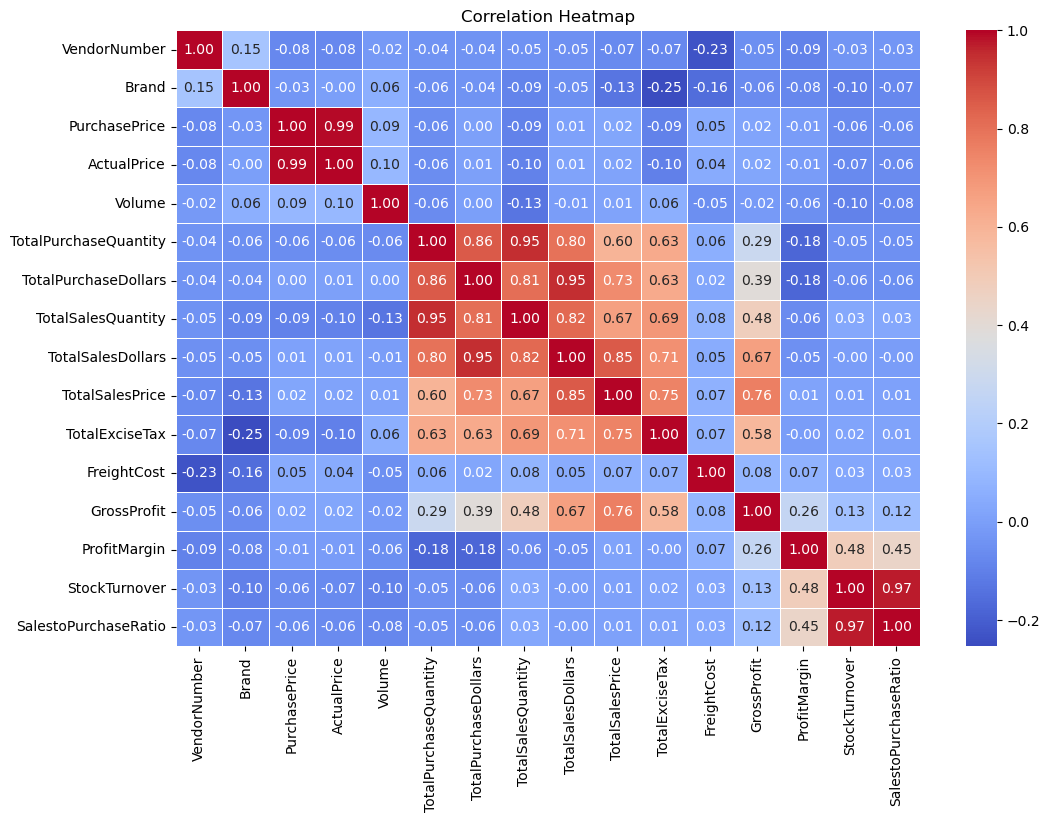

In [61]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot =True, fmt=".2f", cmap="coolwarm", linewidth=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [62]:
# Identify Brands that needs Promotional or pricing Adjustments which exhibit lower sales performance but higher profit margins
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

In [63]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [64]:
low_sales_threshold

117.98

In [65]:
high_margin_threshold

86.42455041969913

In [66]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with Low Sales but High Profit Margin:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margin:


,Description,TotalSalesDollars,ProfitMargin
915,Tracia Syrah,44.94,88.495772
64,Bacardi Oakheart Spiced Trav,59.94,87.554221
272,Chicken & Turkey Cotes du Rh,59.94,90.990991
349,Dr McGillicuddy's Apple Pie,62.72,96.269133
837,St Elder Elderflower Liqueur,66.33,91.436756
46,Aresti Pnt Nr Curico Vly,74.85,95.617902
324,DeKuyper Buttershots Trav,76.93,90.718835
900,Three Olives Grape Vodka,80.19,99.114603
838,St Germain Liqueur,89.94,87.658439
699,Piehole Apple Pie,98.01,95.592287


In [67]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000] #for better visualization

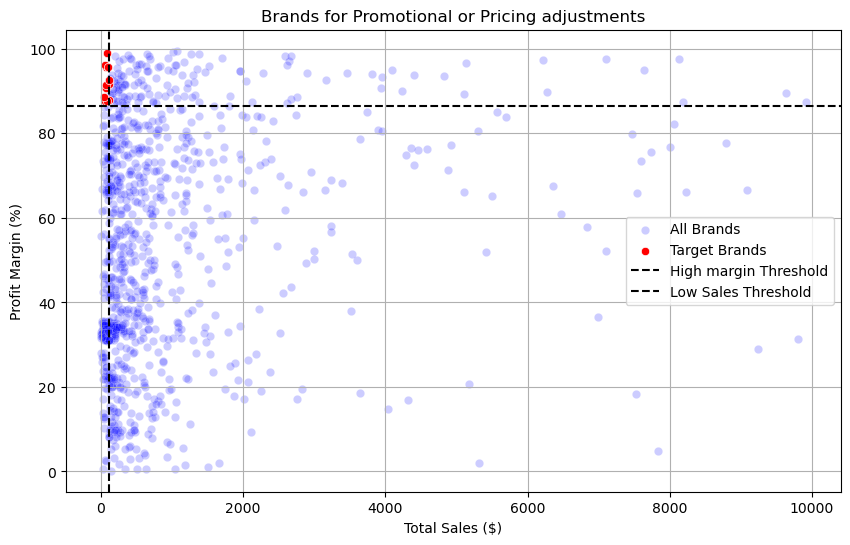

In [68]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing adjustments")
plt.legend()
plt.grid(True)
plt.show()

In [69]:
# Which vendors and brands demonstrate the highest sales performance?
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [70]:
# Top Vendors & Brands by Sales Performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
MARTIGNETTI COMPANIES         243980.10
CONSTELLATION BRANDS INC      180305.21
ULTRA BEVERAGE COMPANY LLP    148726.20
M S WALKER INC                117693.77
PERFECTA WINES                114277.24
BACARDI USA INC                61602.49
BROWN-FORMAN CORP              46884.09
DIAGEO NORTH AMERICA INC       42011.94
JIM BEAM BRANDS COMPANY        41429.49
SOUTHERN WINE & SPIRITS NE     40497.96
Name: TotalSalesDollars, dtype: float64

In [71]:
top_brands

Description
Simi Chard                      93369.42
Simi Cab Svgn                   46523.13
Banfi Centine Mntcln Tscna      31728.09
Rodney Strong Cab Svgn          31245.60
Ch La Rousseliere St Estephe    29698.02
Buehler Chard RRV               27397.25
Madison's Ranch Cab Svgn        24797.91
Rodney Strong Chard             20080.57
Cava Mistinguett Brut           18241.17
Bacardi Twin Pack 2/750mls      17331.33
Name: TotalSalesDollars, dtype: float64

In [72]:
top_brands.apply(lambda x : format_dollars(x))

Description
Simi Chard                      93.37K
Simi Cab Svgn                   46.52K
Banfi Centine Mntcln Tscna      31.73K
Rodney Strong Cab Svgn          31.25K
Ch La Rousseliere St Estephe    29.70K
Buehler Chard RRV               27.40K
Madison's Ranch Cab Svgn        24.80K
Rodney Strong Chard             20.08K
Cava Mistinguett Brut           18.24K
Bacardi Twin Pack 2/750mls      17.33K
Name: TotalSalesDollars, dtype: object

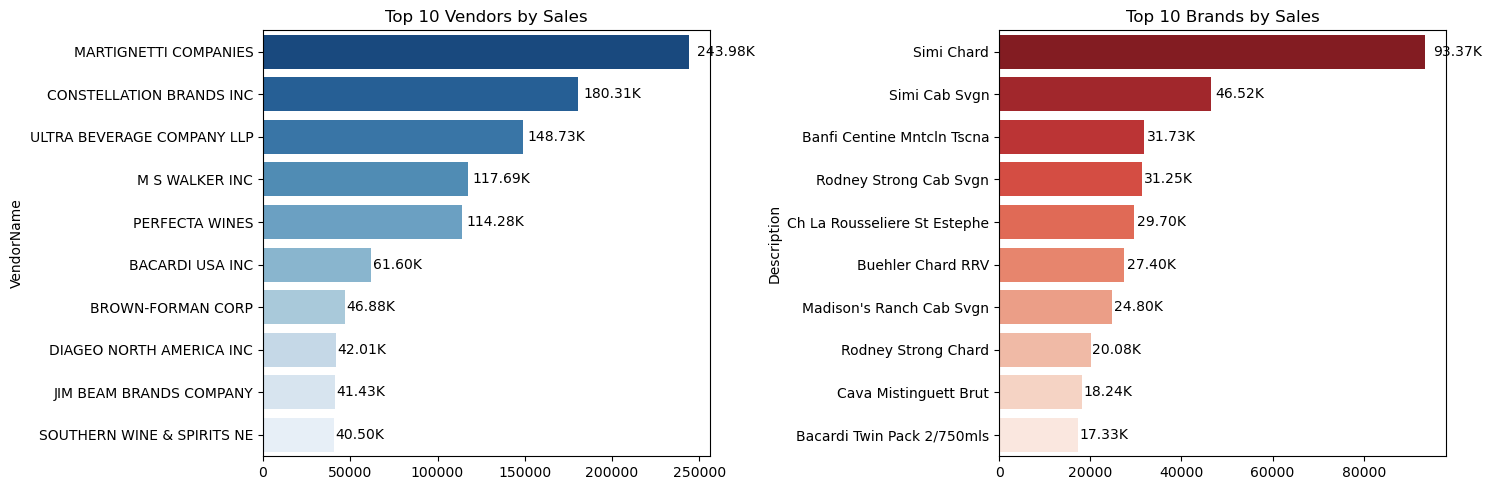

In [73]:
plt.figure(figsize=(15,5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

In [74]:
# Which vendors contribute the most to total purchase?
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()
vendor_performance.shape

(72, 4)

In [75]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100

In [76]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending = False),2)

In [77]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
9,CONSTELLATION BRANDS INC,155.18K,25.12K,180.31K,21.19
33,MARTIGNETTI COMPANIES,106.12K,137.86K,243.98K,14.49
42,PERFECTA WINES,65.88K,48.39K,114.28K,8.99
63,ULTRA BEVERAGE COMPANY LLP,56.97K,91.76K,148.73K,7.78
31,M S WALKER INC,46.58K,71.11K,117.69K,6.36
3,BANFI PRODUCTS CORP,33.93K,3.67K,37.59K,4.63
2,BACARDI USA INC,30.94K,30.66K,61.60K,4.22
14,DIAGEO NORTH AMERICA INC,20.88K,21.13K,42.01K,2.85
26,JIM BEAM BRANDS COMPANY,18.69K,22.74K,41.43K,2.55
55,STATE WINE & SPIRITS,15.26K,22.06K,37.32K,2.08


In [78]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
9,CONSTELLATION BRANDS INC,155.18K,25.12K,180.31K,21.19,21.19
33,MARTIGNETTI COMPANIES,106.12K,137.86K,243.98K,14.49,35.68
42,PERFECTA WINES,65.88K,48.39K,114.28K,8.99,44.67
63,ULTRA BEVERAGE COMPANY LLP,56.97K,91.76K,148.73K,7.78,52.45
31,M S WALKER INC,46.58K,71.11K,117.69K,6.36,58.81
3,BANFI PRODUCTS CORP,33.93K,3.67K,37.59K,4.63,63.44
2,BACARDI USA INC,30.94K,30.66K,61.60K,4.22,67.66
14,DIAGEO NORTH AMERICA INC,20.88K,21.13K,42.01K,2.85,70.51
26,JIM BEAM BRANDS COMPANY,18.69K,22.74K,41.43K,2.55,73.06
55,STATE WINE & SPIRITS,15.26K,22.06K,37.32K,2.08,75.14


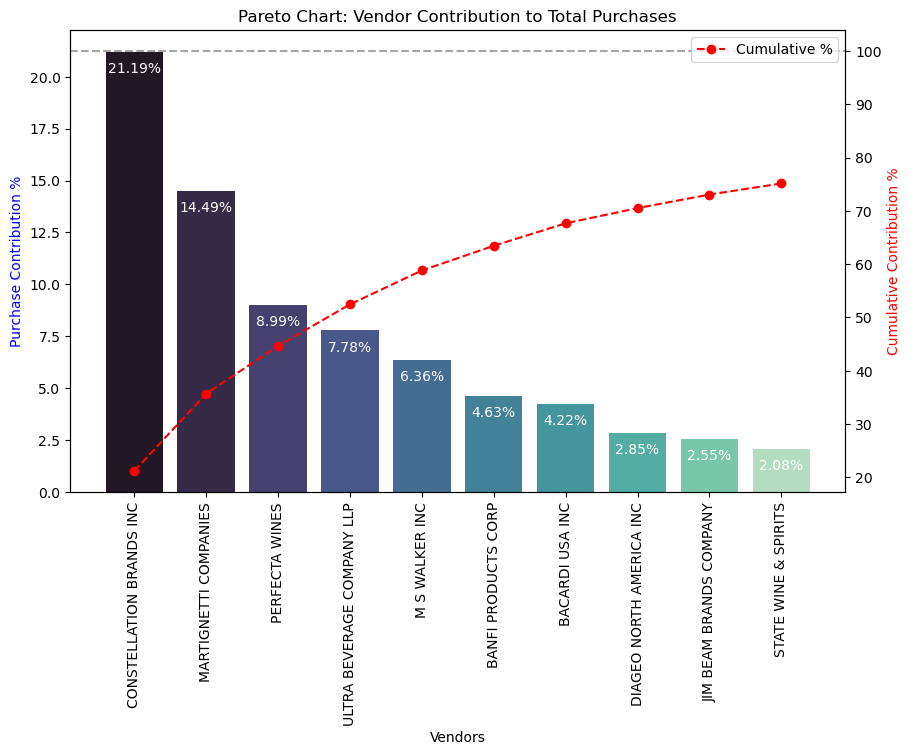

In [79]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value-1, str(value)+'%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative %')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

In [80]:
# How much of total procurement is dependent on the top vendors?
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}%")

Total Purchase Contribution of top 10 vendors is 75.14%


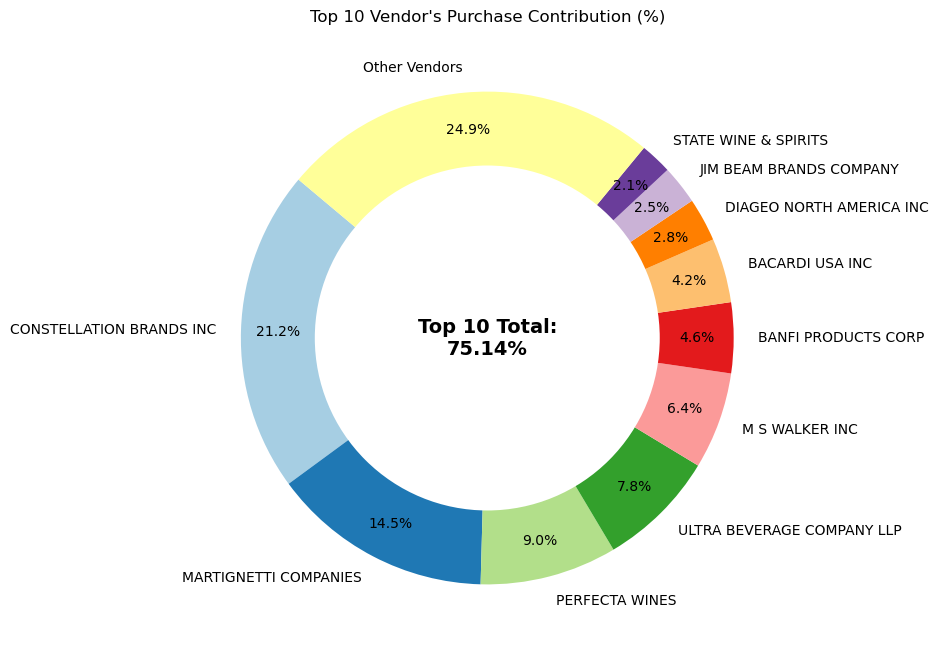

In [81]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append Other Vendors Category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                 startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a donut effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings?

In [82]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [83]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio,UnitPurchasePrice
0,1392,CONSTELLATION BRANDS INC,6650,Simi Chard,7.38,14.99,750.0,11199,82648.62,8458.0,93369.42,13558.87,949.79,79528.99,10720.80,11.482132,0.755246,1.129715,7.38
1,1392,CONSTELLATION BRANDS INC,22143,Simi Cab Svgn,10.52,18.99,750.0,4194,44120.88,2887.0,46523.13,13703.56,323.21,79528.99,2402.25,5.163561,0.688364,1.054447,10.52
2,516,BANFI PRODUCTS CORP,18152,Banfi Centine Mntcln Tscna,5.26,10.99,750.0,5723,30102.98,3891.0,31728.09,7605.68,436.17,8510.41,1625.11,5.121991,0.679888,1.053985,5.26
3,10754,PERFECTA WINES,25197,Ch La Rousseliere St Estephe,99.33,149.99,750.0,249,24733.17,198.0,29698.02,1199.92,22.24,28720.52,4964.85,16.717781,0.795181,1.200737,99.33
4,4425,MARTIGNETTI COMPANIES,8781,Rodney Strong Cab Svgn,10.32,15.99,750.0,2241,23127.12,1840.0,31245.60,11934.97,205.53,144929.24,8118.48,25.982794,0.821062,1.351037,10.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,90024,VINILANDIA USA,46135,Aresti Pnt Nr Curico Vly,3.28,10.99,750.0,1,3.28,15.0,74.85,39.92,1.68,2802.64,71.57,95.617902,15.000000,22.820122,3.28
978,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,3.0,5.97,5.97,0.33,27100.41,3.33,55.778894,1.500000,2.261364,1.32
979,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,128.0,62.72,0.98,6.72,50293.62,60.38,96.269133,21.333333,26.803419,0.39
980,9815,WINE GROUP INC,22407,Three Wishes Chard,2.25,3.29,750.0,1,2.25,1.0,3.29,3.29,0.11,27100.41,1.04,31.610942,1.000000,1.462222,2.25


In [84]:
 df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels={"Small", "Medium", "Large"})

In [85]:
df["OrderSize"]

0      Medium
1      Medium
2      Medium
3      Medium
4      Medium
        ...  
977     Small
978     Small
979     Small
980     Small
981     Small
Name: OrderSize, Length: 982, dtype: category
Categories (3, object): ['Small' < 'Large' < 'Medium']

In [86]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,35.900600
Large,20.687564
Medium,11.248938


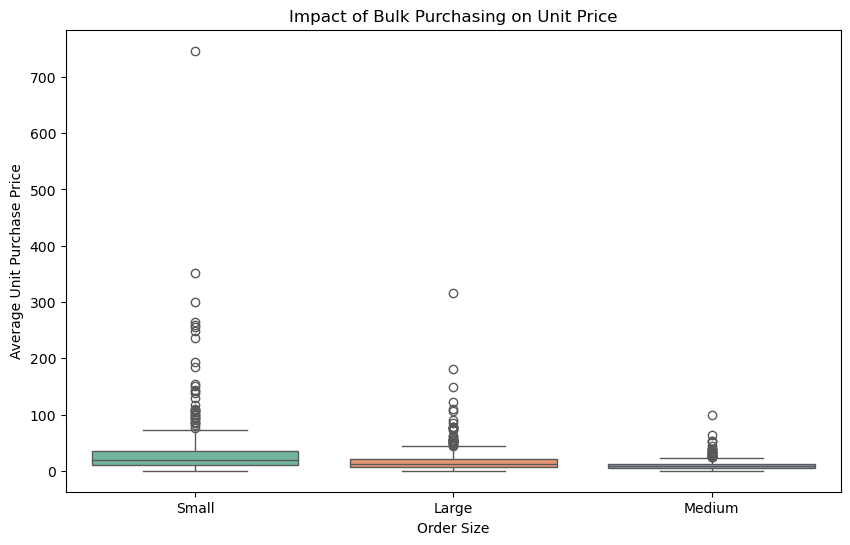

In [87]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

Which Vendors have low inventory turnover, indicating excess stock and slow-moving products?

In [88]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending = True).head(10)

,StockTurnover
VendorName,
PALM BAY INTERNATIONAL INC,0.666667
WILLIAM GRANT & SONS INC,0.695652
WINE GROUP INC,0.704774
TREASURY WINE ESTATES,0.705882
CONSTELLATION BRANDS INC,0.726606
BANFI PRODUCTS CORP,0.727246
STE MICHELLE WINE ESTATES,0.727273
E & J GALLO WINERY,0.730680
Russian Standard Vodka,0.730769


How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

In [89]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold capital: -250988.90000000002


In [90]:
# Aggregate capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the highest locked capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
9,CONSTELLATION BRANDS INC,35.23K
3,BANFI PRODUCTS CORP,9.89K
62,TRINCHERO FAMILY ESTATES,3.80K
23,FREDERICK WILDMAN & SONS,3.11K
71,WINE GROUP INC,2.58K
53,SIDNEY FRANK IMPORTING CO,561.55
64,VINEXTRA INC,201.57
39,NICHE W & S,192.72
61,TREASURY WINE ESTATES,190.9
40,OLE SMOKY DISTILLERY LLC,135.6


What is the 95% confidence intervals for profit margins of top-performing and low-performimg vendors.

In [91]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [92]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] >= low_threshold]["ProfitMargin"].dropna()

In [93]:
low_vendors

0      11.482132
1       5.163561
2       5.121991
3      16.717781
4      25.982794
         ...    
958    97.617964
960    97.231847
969    98.646644
971    99.560050
975    98.226210
Name: ProfitMargin, Length: 736, dtype: float64

In [94]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (57.47, 64.50), Mean: 60.99
Low Vendors 95% CI: (53.75, 57.79), Mean: 55.77


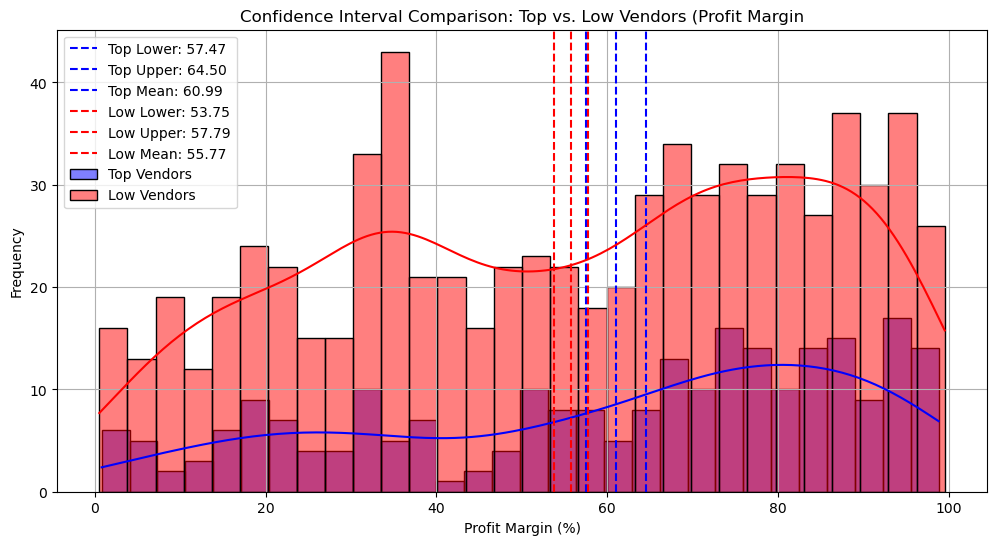

In [95]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="--", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="--", label=f"Low Mean: {low_mean:.2f}")

#Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


Is there any significant difference in profit margins between top-performing and low-performing vendors?

Hypothesis:

H0 (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H1 (Alternate Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [96]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] >= low_threshold]["ProfitMargin"].dropna()
# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistics: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H0: There is a significant difference in profit margins of top and low-performing vendors.")
else:
    print("Fail to Reject H0: No significant difference in profit margin.")

T-Statistics: 2.5321, P-Value: 0.0117
Reject H0: There is a significant difference in profit margins of top and low-performing vendors.


In [100]:
df.to_csv("vendor_sales_summary.csv", index=False)